In [68]:

# Library imports
import pandas as pd
import numpy as np
import mlflow
from sklearn.model_selection import train_test_split
from pyspark.sql.functions import col, to_date, datediff, unix_timestamp, lead, when, year
from pyspark.sql.types import IntegerType
from pyspark.sql import Window
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
import requests
import json
from urllib.parse import quote
import logging
from datetime import datetime
import matplotlib.pyplot as plt

# Get the Dataset

In [69]:
# Load the California housing dataset
housing = fetch_california_housing()
df_features = pd.DataFrame(housing.data, columns=housing.feature_names)
df_target = pd.DataFrame(housing.target, columns=housing.target_names)
df_combined = pd.concat([df_features, df_target], axis=1)  # add columns


# Clean the Data

In [70]:
"""
Cell generated by Data Wrangler.
"""
def clean_data(df):
    # Rename column 'MedInc' to 'MedianIncome'
    df = df.rename(columns={'MedInc': 'MedianIncome'})
    # Rename column 'AveRooms' to 'AvgRooms'
    df = df.rename(columns={'AveRooms': 'AvgRooms'})
    # Rename column 'AveBedrms' to 'AvgBedrms'
    df = df.rename(columns={'AveBedrms': 'AvgBedrms'})
    # Round down column 'AvgRooms'
    df[['AvgRooms']] = np.floor(df[['AvgRooms']])
    # Round column 'AveOccup' (Number of decimals: 1)
    df = df.round({'AveOccup': 1})
    # Round column 'AvgBedrms' (Number of decimals: 1)
    df = df.round({'AvgBedrms': 1})
    df['MedianIncome'] = df['MedianIncome'] * 10000
    df['MedHouseVal'] = df['MedHouseVal'] * 100000
    # Round up column 'MedianIncome'
    df[['MedianIncome']] = np.ceil(df[['MedianIncome']])
    return df

df_clean = clean_data(df_combined.copy())
df_clean.head()

,MedianIncome,HouseAge,AvgRooms,AvgBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,83252.0,41.0,6.0,1.0,322.0,2.6,37.88,-122.23,452600.0
1,83014.0,21.0,6.0,1.0,2401.0,2.1,37.86,-122.22,358500.0
2,72574.0,52.0,8.0,1.1,496.0,2.8,37.85,-122.24,352100.0
3,56431.0,52.0,5.0,1.1,558.0,2.5,37.85,-122.25,341300.0
4,38462.0,52.0,6.0,1.1,565.0,2.2,37.85,-122.25,342200.0


In [71]:
import reverse_geocoder as rg
# Assuming df_clean is a DataFrame with 'Latitude' and 'Longitude' columns
# Convert to list of tuples
coords = list(zip(df_clean['Latitude'], df_clean['Longitude']))

# Apply reverse geocoding
results = rg.search(coords)

# Turn results into DataFrame and join
results_df = pd.DataFrame(results)
df = pd.concat([df_clean, results_df], axis=1)

print(df)


       MedianIncome  HouseAge  AvgRooms  AvgBedrms  Population  AveOccup  \
0           83252.0      41.0       6.0        1.0       322.0       2.6   
1           83014.0      21.0       6.0        1.0      2401.0       2.1   
2           72574.0      52.0       8.0        1.1       496.0       2.8   
3           56431.0      52.0       5.0        1.1       558.0       2.5   
4           38462.0      52.0       6.0        1.1       565.0       2.2   
...             ...       ...       ...        ...         ...       ...   
20635       15603.0      25.0       5.0        1.1       845.0       2.6   
20636       25568.0      18.0       6.0        1.3       356.0       3.1   
20637       17000.0      17.0       5.0        1.1      1007.0       2.3   
20638       18672.0      18.0       5.0        1.2       741.0       2.1   
20639       23886.0      16.0       5.0        1.2      1387.0       2.6   

       Latitude  Longitude  MedHouseVal       lat         lon  \
0         37.88    -12

# Exploratory Data Analysis

<Axes: xlabel='Longitude', ylabel='Latitude'>

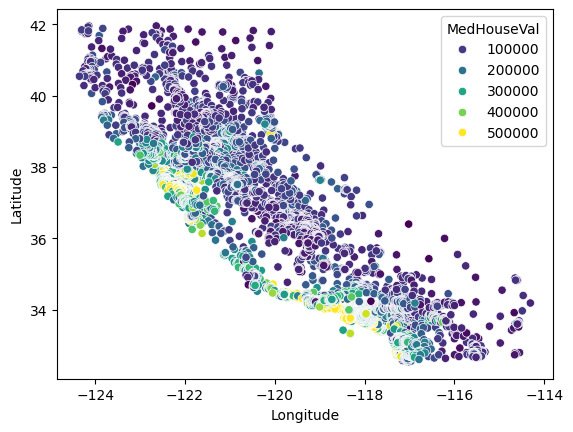

In [72]:
import seaborn as sns
sns.scatterplot(data=df, x="Longitude", y="Latitude", hue="MedHouseVal", palette="viridis")


<Axes: >

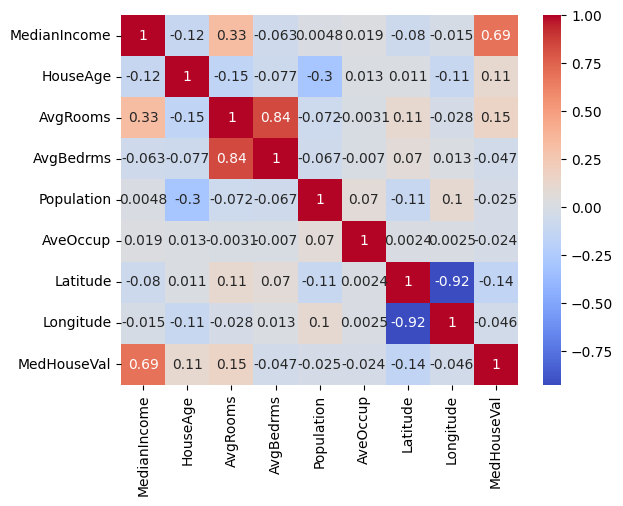

In [73]:

sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")


# Feature Engineering

In [78]:
"""
Feature Engineering.
"""
def feature_engineering(df):
    # Categorize MedianIncome into groups
    df['IncomeCategory'] = pd.cut(df['MedianIncome'], 
                                  bins=[0, 50000, 100000, float('inf')], 
                                  labels=['Low', 'Medium', 'High'])
    # Categorize house age into bins
    bins = [0, 20, 40, 60, 80, 100]
    labels = ['0-20', '21-40', '41-60', '61-80', '81-100']
    df['HouseAgeCategory'] = pd.cut(df['HouseAge'], bins=bins, labels=labels)
    df['bedrooms_per_room'] = df['AvgBedrms'] / df['AvgRooms']
    df['rooms_per_person'] = df['AvgRooms'] / df['AveOccup']
    df = df.rename(columns={'name': 'City'})
    # Rename column 'admin1' to 'State'
    df = df.rename(columns={'admin1': 'State'})
    # Rename column 'admin2' to 'County'
    df = df.rename(columns={'admin2': 'County'})
    # Rename column 'cc' to 'Country'
    df = df.rename(columns={'cc': 'Country'})
    # Drop columns: 'lat', 'lon'
    df = df.drop(columns=['lat', 'lon'])
    return df

df_engineered = feature_engineering(df)
df_engineered.head()

,MedianIncome,HouseAge,AvgRooms,AvgBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,City,State,County,Country,IncomeCategory,HouseAgeCategory,bedrooms_per_room,rooms_per_person
0,83252.0,41.0,6.0,1.0,322.0,2.6,37.88,-122.23,452600.0,Berkeley,California,Alameda County,US,Medium,41-60,0.166667,2.307692
1,83014.0,21.0,6.0,1.0,2401.0,2.1,37.86,-122.22,358500.0,Piedmont,California,Alameda County,US,Medium,21-40,0.166667,2.857143
2,72574.0,52.0,8.0,1.1,496.0,2.8,37.85,-122.24,352100.0,Piedmont,California,Alameda County,US,Medium,41-60,0.137500,2.857143
3,56431.0,52.0,5.0,1.1,558.0,2.5,37.85,-122.25,341300.0,Berkeley,California,Alameda County,US,Medium,41-60,0.220000,2.000000
4,38462.0,52.0,6.0,1.1,565.0,2.2,37.85,-122.25,342200.0,Berkeley,California,Alameda County,US,Low,41-60,0.183333,2.727273


# Feature and Target Selection

In [75]:
"""
Feature and Target Selection
"""
# Define feature columns again
features_to_keep = [
    'MedianIncome',
    'AvgRooms',
    'AvgBedrms',
    'AveOccup',
    'HouseAge',
    'IncomeCategory',
    'HouseAgeCategory',
    'bedrooms_per_room',
    'rooms_per_person',
    'City',
    'State',
    'County'
]

# Define target column
target_col = 'MedHouseVal'

# Select relevant columns from the DataFrame
selected_cols = features_to_keep + [target_col]
df_housing = df_engineered[selected_cols]

# Drop rows with missing values
df_housing = df_housing.dropna()

# Scale numerical features
df_housing['MedianIncome'] = df_housing['MedianIncome'] / 10000
df_housing['MedHouseVal'] = df_housing['MedHouseVal'] / 100000

# Split into features (X) and target (y)
X = df_housing[features_to_keep]
y = df_housing[target_col]

# Primary Preprocessing

In [76]:
# Define categorical and numeric columns

# Check column types
print(df_housing.dtypes)

# Look for object or categorical columns
categorical_cols = df_housing.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))
# Look for numeric columns
numeric_cols = df_housing.select_dtypes(include=['number']).columns
print("Numeric columns:", list(numeric_cols))

# One-hot encode them
df_encoded = pd.get_dummies(df_housing, columns=categorical_cols, drop_first=True, dtype=float)



MedianIncome          float64
AvgRooms              float64
AvgBedrms             float64
AveOccup              float64
HouseAge              float64
IncomeCategory       category
HouseAgeCategory     category
bedrooms_per_room     float64
rooms_per_person      float64
City                   object
State                  object
County                 object
MedHouseVal           float64
dtype: object
Categorical columns: ['IncomeCategory', 'HouseAgeCategory', 'City', 'State', 'County']
Numeric columns: ['MedianIncome', 'AvgRooms', 'AvgBedrms', 'AveOccup', 'HouseAge', 'bedrooms_per_room', 'rooms_per_person', 'MedHouseVal']


# Second Preprocessing Method

In [77]:
# # Define categorical and numeric columns

# # Check column types
# print(df_housing.dtypes)

# # Look for object or categorical columns
# categorical_cols = df_housing.select_dtypes(include=['object', 'category']).columns
# print("Categorical columns:", list(categorical_cols))
# # Look for numeric columns
# numeric_cols = df_housing.select_dtypes(include=['number']).columns
# print("Numeric columns:", list(numeric_cols))

# # Preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         (
#             "num",
#             Pipeline(
#                 [
#                     ("imputer", SimpleImputer(strategy="mean")),
#                     ("scaler", StandardScaler()),
#                 ]
#             ),
#             numeric_cols,
#         ),
#         (
#             "cat",
#             Pipeline(
#                 [
#                     ("imputer", SimpleImputer(strategy="most_frequent")),
#                     ("onehot", OneHotEncoder(handle_unknown="ignore")),
#                 ]
#             ),
#             categorical_cols,
#         ),
#     ]
# )

# # Now X and y are ready to be used in a model pipeline

# Modeling
Type: Neural Network

    Split into train/dev/test
    Model Training
    Model Evaluation
    Calibration

In [ ]:
# Enable MLflow autologging
mlflow.autolog()